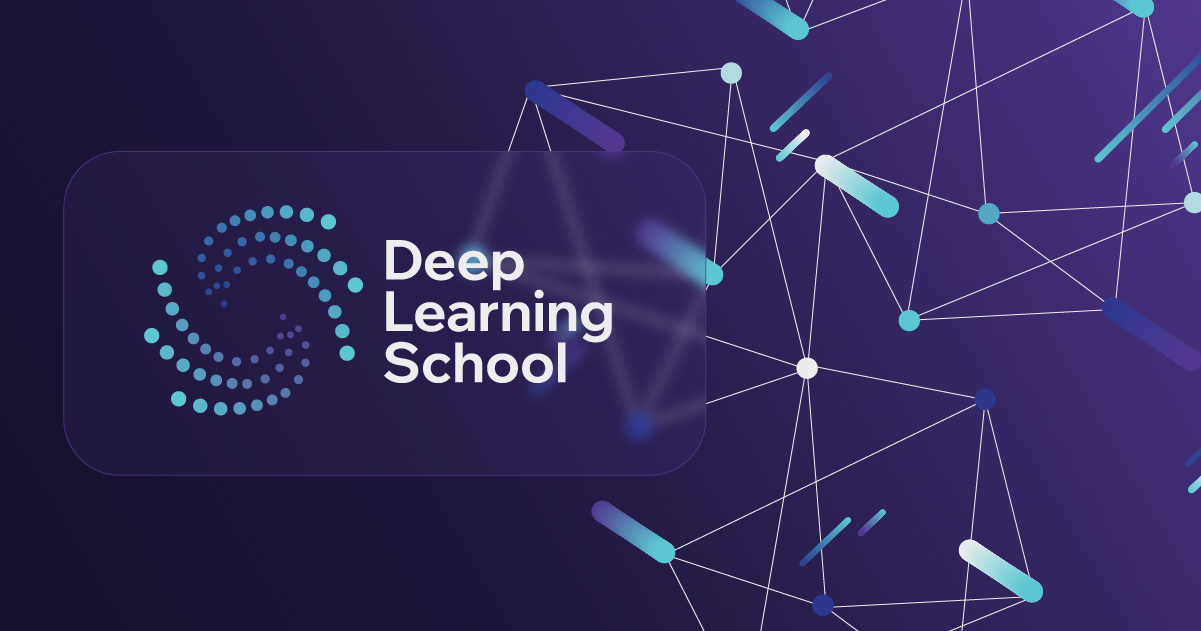

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

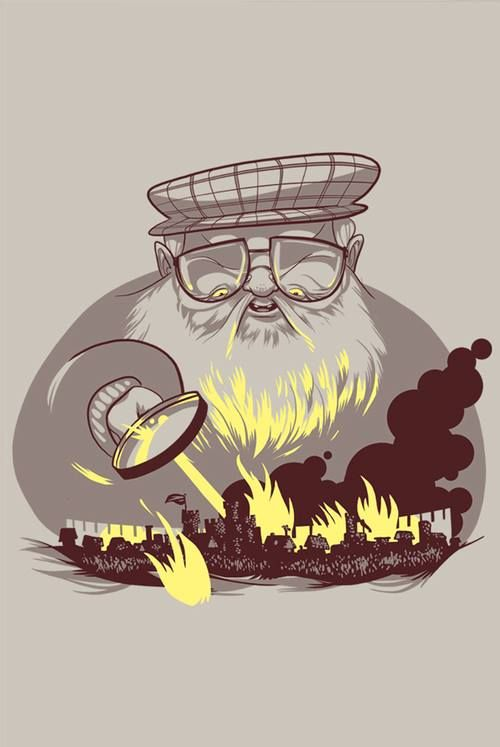

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 57.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 4.80MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [3]:
data = pd.read_csv("/content/game_of_thrones_train.csv", index_col='S.No')
print(f"Датасет загружен. Размер: {data.shape}")
print("\nТипы данных:")
print(data.dtypes)

Датасет загружен. Размер: (1557, 25)

Типы данных:
name                 object
title                object
male                  int64
culture              object
dateOfBirth         float64
mother               object
father               object
heir                 object
house                object
spouse               object
book1                 int64
book2                 int64
book3                 int64
book4                 int64
book5                 int64
isAliveMother       float64
isAliveFather       float64
isAliveHeir         float64
isAliveSpouse       float64
isMarried             int64
isNoble               int64
age                 float64
numDeadRelations      int64
popularity          float64
isAlive               int64
dtype: object


Посмотрите, какие типы данных представлены в нашем датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [4]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [5]:
data.describe(include = [np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [6]:
# Анализ пропущенных значений
print("Количество NaN в каждом столбце:")
print(data.isnull().sum())
print("\nДоля NaN в каждом столбце:")
print(data.isnull().mean().round(2))

Количество NaN в каждом столбце:
name                   0
title                840
male                   0
culture             1069
dateOfBirth         1278
mother              1539
father              1535
heir                1536
house                381
spouse              1357
book1                  0
book2                  0
book3                  0
book4                  0
book5                  0
isAliveMother       1539
isAliveFather       1535
isAliveHeir         1536
isAliveSpouse       1357
isMarried              0
isNoble                0
age                 1278
numDeadRelations       0
popularity             0
isAlive                0
dtype: int64

Доля NaN в каждом столбце:
name                0.00
title               0.54
male                0.00
culture             0.69
dateOfBirth         0.82
mother              0.99
father              0.99
heir                0.99
house               0.24
spouse              0.87
book1               0.00
book2               0.00
b

В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

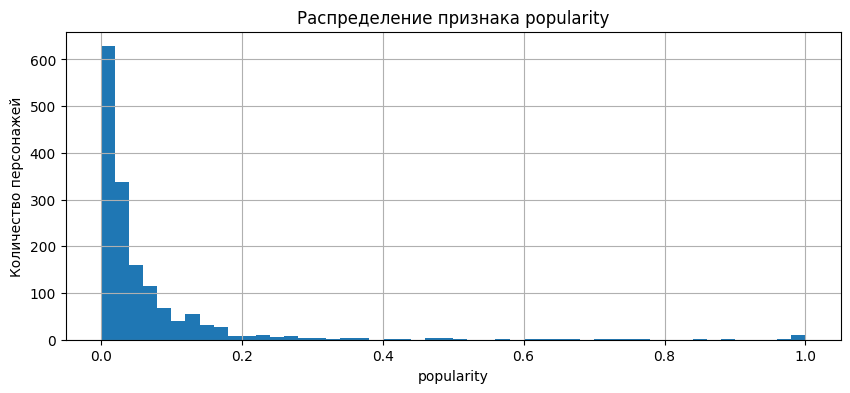

Описание признака popularity:
count    1557.000000
mean        0.062400
std         0.121416
min         0.000000
25%         0.013378
50%         0.023411
75%         0.063545
max         1.000000
Name: popularity, dtype: float64


In [7]:
# Гистограмма распределения признака popularity
data['popularity'].hist(bins=50, figsize=(10,4))
plt.title('Распределение признака popularity')
plt.xlabel('popularity')
plt.ylabel('Количество персонажей')
plt.show()
print("Описание признака popularity:")
print(data['popularity'].describe())

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


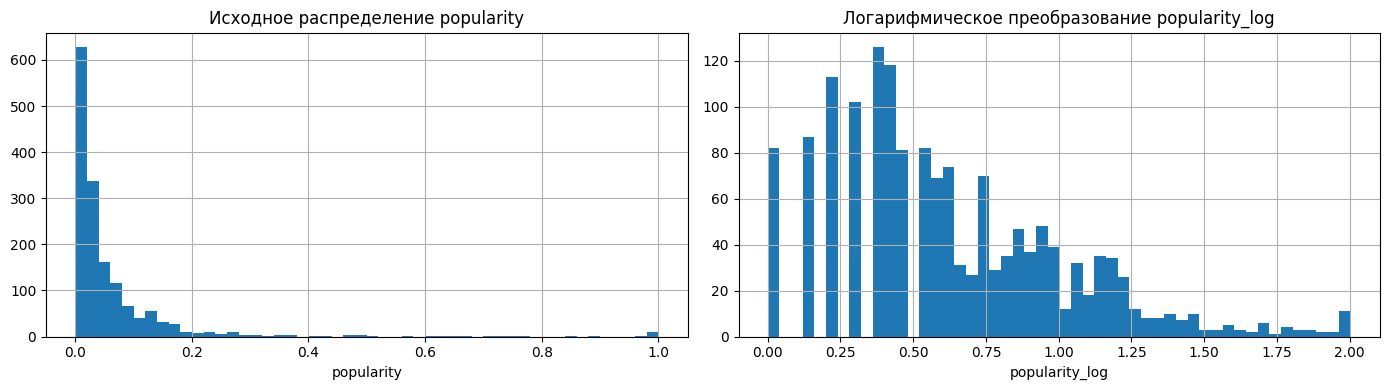

popularity_log создан


In [8]:
# Логарифмическое преобразование признака popularity
M = 100
data['popularity_log'] = np.log10(data['popularity'] * M + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
data['popularity'].hist(bins=50, ax=axes[0])
axes[0].set_title('Исходное распределение popularity')
axes[0].set_xlabel('popularity')

data['popularity_log'].hist(bins=50, ax=axes[1])
axes[1].set_title('Логарифмическое преобразование popularity_log')
axes[1].set_xlabel('popularity_log')

plt.tight_layout()
plt.show()
print("popularity_log создан")

В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [9]:
# Частотное распределение numDeadRelations
print("Частотное распределение numDeadRelations:")
print(data['numDeadRelations'].value_counts())

# Создаем бинарный признак boolDeadRelations
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)
print("\nРаспределение boolDeadRelations:")
print(data['boolDeadRelations'].value_counts())

Частотное распределение numDeadRelations:
numDeadRelations
0     1488
1       24
5       10
7        7
4        7
3        4
10       4
2        4
6        3
8        2
12       1
11       1
15       1
9        1
Name: count, dtype: int64

Распределение boolDeadRelations:
boolDeadRelations
0    1488
1      69
Name: count, dtype: int64


Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [10]:
data['age_value'] = data['age'].fillna(0)  # ДОБАВЬТЕ ВАШ КОД
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]
print("age_value и age_no_data созданы")
print(data[['age', 'age_value', 'age_no_data']].head(10))

age_value и age_no_data созданы
       age  age_value  age_no_data
S.No                              
1      NaN        0.0            1
2     97.0       97.0            0
3      NaN        0.0            1
4     23.0       23.0            0
5     29.0       29.0            0
6      NaN        0.0            1
7     26.0       26.0            0
8      NaN        0.0            1
9      NaN        0.0            1
10     NaN        0.0            1


Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [11]:
data['culture'].value_counts(dropna=False)  # ДОБАВЬТЕ ВАШ КОД

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [12]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [13]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [14]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
    for v in cultures_grouped[k]:
        cultures_grouped_inverted[v] = k

print(f"cultures_grouped_inverted создан, всего записей: {len(cultures_grouped_inverted)}")
cultures_grouped_inverted

cultures_grouped_inverted создан, всего записей: 59


{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [15]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [16]:
# Заменяем NaN в culture_grouped на 'culture_no_data'
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')
print("Распределение culture_grouped:")
print(data['culture_grouped'].value_counts())

Распределение culture_grouped:
culture_grouped
culture_no_data              1069
Essos Nations                 109
the North                     108
the Iron Islands               95
Other Nations                  57
Old Nations                    32
the Mountain and the Vale      25
Dorne                          21
the Rock                       14
the Reach                      13
the Isles and Rivers           10
the Stormlands                  4
Name: count, dtype: int64


Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [17]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
culture,51
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186


In [18]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include = [np.number]).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.000000,2
dateOfBirth,279.0,-25.0,299.000000,105
book1,1557.0,0.0,1.000000,2
book2,1557.0,0.0,1.000000,2
book3,1557.0,0.0,1.000000,2
book4,1557.0,0.0,1.000000,2
book5,1557.0,0.0,1.000000,2
isAliveMother,18.0,0.0,1.000000,2
isAliveFather,22.0,0.0,1.000000,2
isAliveHeir,21.0,0.0,1.000000,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [19]:
# Сравнение средних зависимой переменной isAlive для признака isAliveSpouse
print("Среднее isAlive по isAliveSpouse:")
print(data.groupby('isAliveSpouse', dropna=False)['isAlive'].agg(['mean', 'count']))

print("\nСреднее isAlive по culture_grouped:")
print(pd.pivot_table(data=data, values='isAlive', index='culture_grouped', aggfunc=['mean', 'count'], dropna=False))

Среднее isAlive по isAliveSpouse:
                   mean  count
isAliveSpouse                 
0.0            0.619048     42
1.0            0.753165    158
NaN            0.786293   1357

Среднее isAlive по culture_grouped:
                               mean   count
                            isAlive isAlive
culture_grouped                            
Dorne                      0.952381      21
Essos Nations              0.834862     109
Old Nations                0.281250      32
Other Nations              0.701754      57
culture_no_data            0.781104    1069
the Iron Islands           0.884211      95
the Isles and Rivers       0.700000      10
the Mountain and the Vale  0.840000      25
the North                  0.777778     108
the Reach                  0.769231      13
the Rock                   0.500000      14
the Stormlands             1.000000       4


**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [20]:
# Задание 1.7: Кодирование признаков

# Binary columns - fill NaN with 0
binary_cols = ['book1', 'book2', 'book3', 'book4', 'book5', 'male', 'isNoble',
               'isMarried', 'isAliveSpouse', 'isAliveMother', 'isAliveHeir', 'isAliveFather']

for col in binary_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0)

print("Binary columns после обработки NaN:")
print(data[binary_cols].isnull().sum())

# One-hot encoding for culture_grouped
culture_dummies = pd.get_dummies(data['culture_grouped'], prefix='culture')
print(f"\nОдин горячий (one-hot) для culture_grouped: {culture_dummies.shape[1]} столбцов")
print(culture_dummies.columns.tolist())

# Correlation matrix for numeric features
numeric_cols = binary_cols + ['popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data', 'isAlive']
corr_matrix = data[numeric_cols].corr()
print("\nКорреляционная матрица (первые 5 столбцов):")
print(corr_matrix[['isAlive']].sort_values('isAlive', ascending=False))

Binary columns после обработки NaN:
book1            0
book2            0
book3            0
book4            0
book5            0
male             0
isNoble          0
isMarried        0
isAliveSpouse    0
isAliveMother    0
isAliveHeir      0
isAliveFather    0
dtype: int64

Один горячий (one-hot) для culture_grouped: 12 столбцов
['culture_Dorne', 'culture_Essos Nations', 'culture_Old Nations', 'culture_Other Nations', 'culture_culture_no_data', 'culture_the Iron Islands', 'culture_the Isles and Rivers', 'culture_the Mountain and the Vale', 'culture_the North', 'culture_the Reach', 'culture_the Rock', 'culture_the Stormlands']

Корреляционная матрица (первые 5 столбцов):
                    isAlive
isAlive            1.000000
book4              0.284014
age_no_data        0.113629
book5              0.032531
book3              0.018427
isAliveSpouse     -0.020436
isMarried         -0.049381
isAliveFather     -0.051718
book2             -0.055998
isNoble           -0.060572
isAliveHei

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

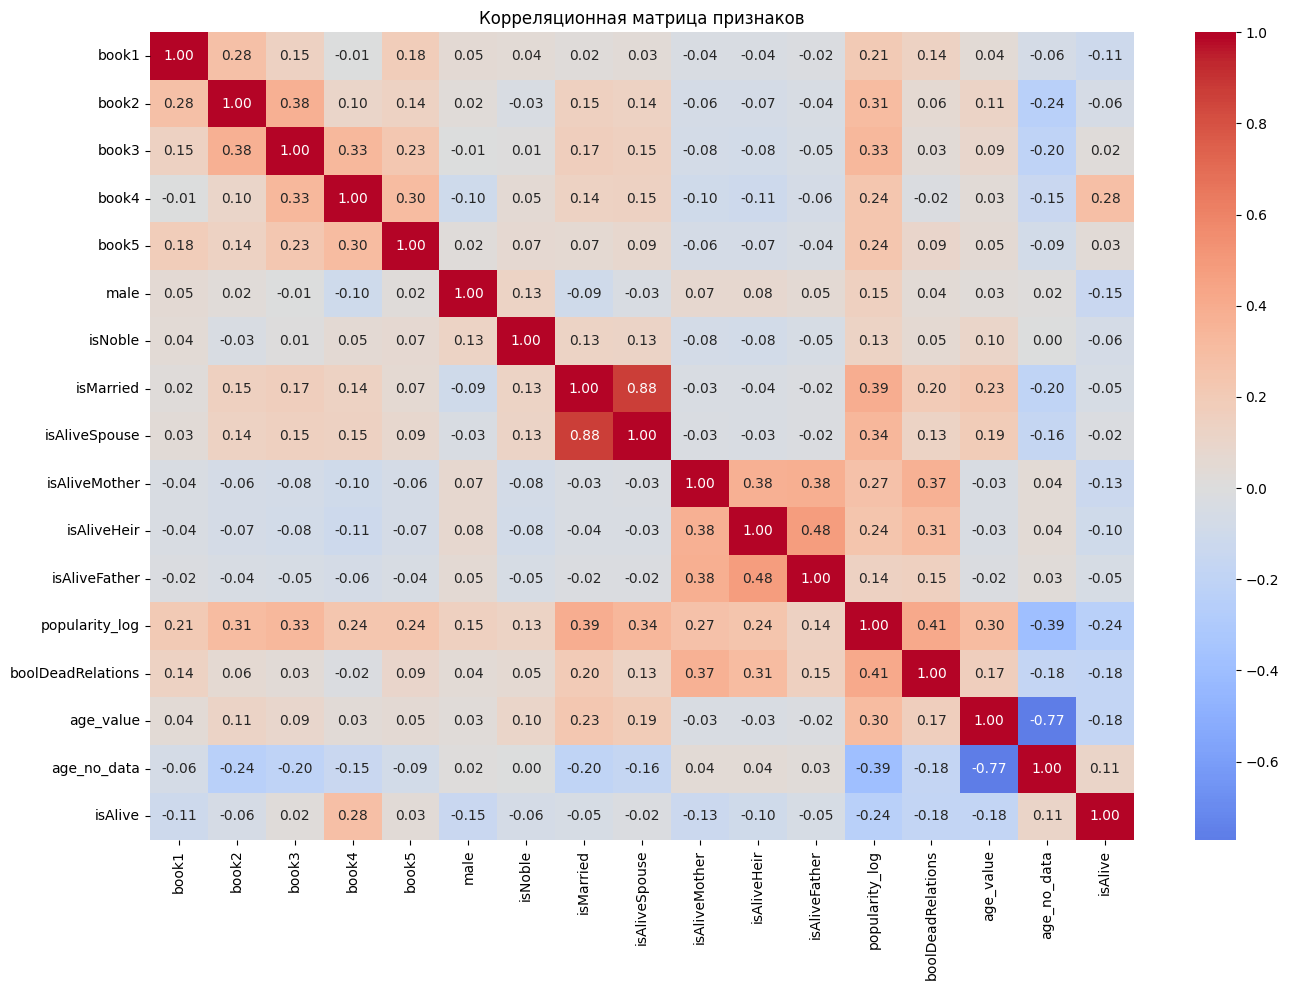


Признаки по корреляции с isAlive:
isAlive              1.000000
book4                0.284014
age_no_data          0.113629
book5                0.032531
book3                0.018427
isAliveSpouse       -0.020436
isMarried           -0.049381
isAliveFather       -0.051718
book2               -0.055998
isNoble             -0.060572
isAliveHeir         -0.096622
book1               -0.112468
isAliveMother       -0.129817
male                -0.148290
boolDeadRelations   -0.178177
age_value           -0.181938
popularity_log      -0.242497
Name: isAlive, dtype: float64


In [21]:
# Задание 1.8: Анализ влияния признаков на целевую переменную

# Тепловая карта корреляций
plt.figure(figsize=(14, 10))
numeric_cols = ['book1', 'book2', 'book3', 'book4', 'book5', 'male', 'isNoble',
                'isMarried', 'isAliveSpouse', 'isAliveMother', 'isAliveHeir',
                'isAliveFather', 'popularity_log', 'boolDeadRelations',
                'age_value', 'age_no_data', 'isAlive']
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

# Топ признаки по корреляции с isAlive
print("\nПризнаки по корреляции с isAlive:")
print(corr['isAlive'].sort_values(ascending=False))

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [22]:
# Задание 1.9: Создание X и y

binary_cols = ['book1', 'book2', 'book3', 'book4', 'book5', 'male', 'isNoble',
               'isMarried', 'isAliveSpouse', 'isAliveMother', 'isAliveHeir', 'isAliveFather']
feature_cols = binary_cols + ['popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data']

culture_dummies = pd.get_dummies(data['culture_grouped'], prefix='culture')

X = pd.concat([data[feature_cols], culture_dummies], axis=1)
y = data['isAlive']

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Признаки: {list(X.columns)}")
print(f"\nРаспределение целевой переменной:")
print(y.value_counts())

Размер X: (1557, 28)
Размер y: (1557,)
Признаки: ['book1', 'book2', 'book3', 'book4', 'book5', 'male', 'isNoble', 'isMarried', 'isAliveSpouse', 'isAliveMother', 'isAliveHeir', 'isAliveFather', 'popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data', 'culture_Dorne', 'culture_Essos Nations', 'culture_Old Nations', 'culture_Other Nations', 'culture_culture_no_data', 'culture_the Iron Islands', 'culture_the Isles and Rivers', 'culture_the Mountain and the Vale', 'culture_the North', 'culture_the Reach', 'culture_the Rock', 'culture_the Stormlands']

Распределение целевой переменной:
isAlive
1    1212
0     345
Name: count, dtype: int64


**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}")

X_train: (1245, 28), X_val: (312, 28)
y_train: (1245,), y_val: (312,)


## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [25]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [26]:
# Шаг 1. Создание моделей
lr_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
dt_model = DecisionTreeClassifier(random_state=42)

# Шаг 2. Обучение моделей
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred_lr = lr_model.predict(X_val)
y_pred_rf = rf_model.predict(X_val)
y_pred_knn = knn_model.predict(X_val)
y_pred_dt = dt_model.predict(X_val)

print("Модели обучены и предсказания сделаны")

Модели обучены и предсказания сделаны


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [27]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [28]:
# Шаг 3. Предсказание на тестовых данных (уже сделано выше)
y_pred = y_pred_rf  # ваш код здесь - используем RandomForest как лучшую модель

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

# Сравнение всех моделей
print("\n=== Сравнение моделей ===")
models = {
    'LogisticRegression': y_pred_lr,
    'RandomForest': y_pred_rf,
    'KNeighbors': y_pred_knn,
    'DecisionTree': y_pred_dt
}

best_model_name = None
best_accuracy = 0
for model_name, y_pred_model in models.items():
    acc = accuracy_score(y_val, y_pred_model)
    print(f"{model_name}: {acc:.4f}")
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = model_name

print(f"\nЛучшая модель: {best_model_name} с Accuracy = {best_accuracy:.4f}")

# Оценка по шкале
if best_accuracy >= 0.65:
    print("Оценка: 5 баллов (score >= 0.65)")
elif best_accuracy >= 0.50:
    print("Оценка: 4 балла (0.50 <= score < 0.65)")
elif best_accuracy >= 0.45:
    print("Оценка: 3 балла (0.45 <= score < 0.50)")
elif best_accuracy >= 0.40:
    print("Оценка: 2 балла (0.40 <= score < 0.45)")
else:
    print("Оценка: менее 2 баллов")

Accuracy : 0.8045

=== Сравнение моделей ===
LogisticRegression: 0.7981
RandomForest: 0.8045
KNeighbors: 0.7788
DecisionTree: 0.7660

Лучшая модель: RandomForest с Accuracy = 0.8045
Оценка: 5 баллов (score >= 0.65)


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [29]:
# Загрузка тестового датасета
data_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')
print(f"Тестовый датасет загружен. Размер: {data_test.shape}")
print("\nОписание числовых признаков:")
print(data_test.describe(include=[np.number]).T[['count', 'min', 'max']])

Тестовый датасет загружен. Размер: (389, 24)

Описание числовых признаков:
                  count       min       max
male              389.0       0.0       1.0
dateOfBirth       154.0     -28.0  298299.0
book1             389.0       0.0       1.0
book2             389.0       0.0       1.0
book3             389.0       0.0       1.0
book4             389.0       0.0       1.0
book5             389.0       0.0       1.0
isAliveMother       3.0       1.0       1.0
isAliveFather       4.0       0.0       0.0
isAliveHeir         2.0       0.0       1.0
isAliveSpouse      76.0       0.0       1.0
isMarried         389.0       0.0       1.0
isNoble           389.0       0.0       1.0
age               154.0 -298001.0     100.0
numDeadRelations  389.0       0.0      15.0
popularity        389.0       0.0       1.0


По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [30]:
#Подсказка
data_test.loc[data_test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1685,Doreah,NaN,0,Lysene,278279.0,NaN,NaN,NaN,House Targaryen,NaN,...,1,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368
1869,Rhaego,NaN,0,NaN,298299.0,NaN,NaN,NaN,House Targaryen,NaN,...,0,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224


In [31]:
#Вы можете аккуратно поправить тестовые данные, воспользовавшись, например следующим кодом:
data_test.loc[1685, 'dateOfBirth'] = 278.
# замены в строке 1685: dateOfBirth -> 278. и age -> 0.
data_test.loc[1685, 'age'] = 0.
# замены в строке 1869: dateOfBirth -> 299. и age -> 0.
data_test.loc[1869, 'dateOfBirth'] = 299.
data_test.loc[1869, 'age'] = 0.

print("Тестовые данные исправлены")
print("Проверяем отрицательные значения age:")
print(data_test[data_test['age'] < 0])

# Применяем тот же пайплайн преобразований к тестовым данным
# 1. popularity_log
data_test['popularity_log'] = np.log10(data_test['popularity'] * 100 + 1)

# 2. boolDeadRelations
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)

# 3. age_value и age_no_data
data_test['age_value'] = data_test['age'].fillna(0)
data_test['age_no_data'] = [1 if np.isnan(x) else 0 for x in data_test['age']]

# 4. culture_grouped
data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

# 5. Binary columns
binary_cols = ['book1', 'book2', 'book3', 'book4', 'book5', 'male', 'isNoble',
               'isMarried', 'isAliveSpouse', 'isAliveMother', 'isAliveHeir', 'isAliveFather']
for col in binary_cols:
    if col in data_test.columns:
        data_test[col] = data_test[col].fillna(0)

# 6. One-hot encoding culture
culture_dummies_test = pd.get_dummies(data_test['culture_grouped'], prefix='culture')

# 7. Создание X_test
feature_cols = binary_cols + ['popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data']
X_test = pd.concat([data_test[feature_cols], culture_dummies_test], axis=1)

# Выравниваем столбцы
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X_train.columns]

print(f"X_test: {X_test.shape}")

# Применяем лучшую модель (RandomForest)
y_test_pred = rf_model.predict(X_test)
print(f"Предсказания сделаны: {pd.Series(y_test_pred).value_counts().to_dict()}")

Тестовые данные исправлены
Проверяем отрицательные значения age:
Empty DataFrame
Columns: [name, title, male, culture, dateOfBirth, mother, father, heir, house, spouse, book1, book2, book3, book4, book5, isAliveMother, isAliveFather, isAliveHeir, isAliveSpouse, isMarried, isNoble, age, numDeadRelations, popularity]
Index: []

[0 rows x 24 columns]
X_test: (389, 28)
Предсказания сделаны: {1: 282, 0: 107}


Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [32]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 10.0MB/s]


In [33]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')
print("Submission файл загружен:")
print(submission.head())

Submission файл загружен:
      isAlive
S.No         
1558        0
1559        0
1560        0
1561        0
1562        0


In [34]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


Как сохранить измененный Pandas DataFrame в csv файл:

In [35]:
# Вставляем предсказания в submission
submission['isAlive'] = y_test_pred
submission.to_csv("/content/new_submission.csv", index=True)
print("Submission сохранен в /content/new_submission.csv")
print(submission.head(10))
print(f"\nРаспределение предсказаний: {pd.Series(y_test_pred).value_counts().to_dict()}")

Submission сохранен в /content/new_submission.csv
      isAlive
S.No         
1558        0
1559        1
1560        1
1561        1
1562        1
1563        0
1564        1
1565        1
1566        0
1567        1

Распределение предсказаний: {1: 282, 0: 107}
